# OpenMP

- API for shared-memory parallelism in C, C++, and Fortran

- Uses threads (not processes) for parallelism

- Follows fork-join model: master thread spawns worker threads

- Relies on compiler directives (#pragma omp ...)

- Enables incremental parallelization (start with one loop, add more)



`#pragma omp construct [clause[clause...]`

# Implementation:
OpenMP in C is implemented primarily through compiler directives (pragmas), specifically #pragma omp ...  plus a small set of runtime functions (omp_set_num_threads(), omp_get_thread_num(), etc.) and environment variables (OMP_NUM_THREADS).



# Example 1: Hello World !!!

In [17]:
%%bash
cat << 'EOF' > code1.c
#include <stdio.h>
#include <omp.h>

int main()
{
    #pragma omp parallel
    // tells OpenMP to start a parallel region.

//The master thread forks worker threads. By default, 
//the number of threads equals the number of CPU cores (or logical processors).
  
  
 // Start of structure block
 {
        int ID = omp_get_thread_num();// id for each thread
        printf("Hello (%d)", ID);
        printf("World (%d)\n", ID);
       
 }  // End of structure block
    return 0;
}
EOF

gcc -fopenmp code1.c -o code1
./code1




# We can use more threads than the CPU cores
#Interleaving threads means that when multiple threads are running, 
#the CPU scheduler switches between them in a way that their 
#instructions get mixed together in time, rather than one thread
#finishing completely before another starts.Below due 
#to the interleaving threads the outputs are going to be interleaved 
#differently each time. The challenge in 
#multi-threaded programming is to manage interleaving

Hello (0)World (0)
Hello (2)World (2)
Hello (3)World (3)
Hello (1)World (1)


# Explanation of above code
```bash 
#pragma omp parallel

- This tells OpenMP to start a parallel region.

- The master thread forks multiple worker threads (default = number of CPU cores, 
unless overridden by OMP_NUM_THREADS).

- CPU (2 physical cores × 2 hyper‑threads = 4 logical CPUs), OpenMP by default spawns one thread per logical CPU.
```

# Multithreading in OpenMP
**Fork join model**

- The program starts with a **`master thread`**
- At some point during the program additional threads are needed.
- Master thread has ID = 0




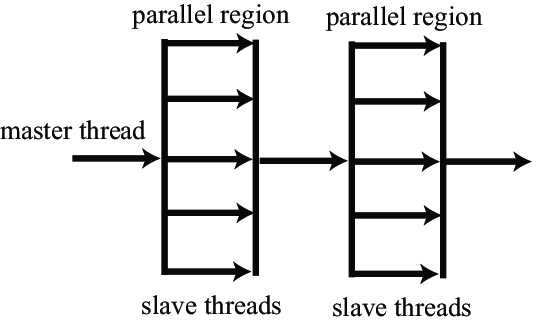





# The hello world expression of openMP


$$\pi = \int_{0}^{1} \frac{4}{1 + x^2} \, dx$$


$$
\pi \approx \Delta x \sum_{i=0}^{N-1} \frac{4}{1 + \left( (i + 0.5) \Delta x \right)^2}, \quad \Delta x = \frac{1}{N}
$$

- Each rectangle width = Δx

- Each rectangle height = f(x) at the midpoint

- Sum them all → approximate π


- **Riemann sum:** a method to approximate the area under a curve by dividing it into rectangles.


<img src="download.png" width="600">

----------------------------------
<img src="download1.png" width="600">








In [3]:
%%bash
cat << 'EOF' > code1.c
#include <stdio.h>
#include <omp.h>
#include <stdio.h>

static long num_steps = 100000;
double step;

int main() {
    int i;
    double x, pi, sum = 0.0;
    
    step =1.0 / (double) num_steps; //each box exactly 0.00001 units WIDE.
    
    for (i = 0; i < num_steps; i++) {
        x = (i +0.5) * step;
        sum += 4.0 / (1.0 + x * x);   // ← FIXED
    }
    
    pi = step * sum;
    printf("π ≈ %.15f\n", pi);
    
    return 0;
}

EOF

gcc -fopenmp code1.c -o code1
./code1


π ≈ 3.141592653598162


In [2]:
%%bash
cat << 'EOF' > code1_seq.c
#include <stdio.h>
#include <omp.h>

static long num_steps = 10000000; 
double step;

int main() {
    int i;
    double x, pi, sum = 0.0;
    double start_time, end_time;

    step = 1.0 / (double) num_steps;  //delta_x

    // Start the stopwatch
    start_time = omp_get_wtime();

    // The Sequential Loop (Single Traveler)
    for (i = 0; i < num_steps; i++) {
        x = (i + 0.5) * step;
        sum += 4.0 / (1.0 + x * x);
    }

    pi = step * sum;
 //     pi =  sum;
    // Stop the stopwatch
    end_time = omp_get_wtime();

    printf("π ≈ %.15f\n", pi);
    printf("Sequential Execution Time: %f seconds\n", end_time - start_time);

    return 0;
}
EOF

gcc -fopenmp code1_seq.c -o code1_seq
./code1_seq

π ≈ 3.141592653589731
Sequential Execution Time: 0.088254 seconds


# Explanation of the above code

- In order to approximate the area under the whole curve from 0 to 1, 
we build small boxes (rectangles) of equal length under the curve.

- If we compute the areas of all these boxes individually (h x w) and sum them up then we
  get the area under the cruve.
  
- The larger the number of boxes, the more accurate approximation of the area under the cruve we get.

- `static long num_steps = 100000;`
If we are walking from x=0 to x=1,  we take 100,000 steps, 
  each step is our box width. 
    
  
- HEIGHT is calculated inside the loop for every single i.

    `4.0 / (1.0 + x * x)` is the value of the f(x) for a specific point. 
    
    
 
*************************************************************************
**Why the (i + 0.5)?**

This is the Midpoint Rule.

- If we used just i * step, we would be taking the height from the left edge of
the box.

- If we used (i + 1) * step, we would be taking the height from the right edge.

- By using (i + 0.5) * step, we are calculating the height at the exact center of the box. This usually gives a much better approximation of the area because the "over-count" on one side of the midpoint roughly cancels out the "under-count" on the other.

***************************************************

**How do we do h x w ?**

- Mathematically, the area of all boxes is:$$\text{Total Area} = (h_1 \times w) + (h_2 \times w) + (h_3 \times w) + \dots + (h_n \times w)$$


- Since the width ($w$) is the same for every box (it's a constant step), we can use the distributive property to pull it out of the sum:$$\text{Total Area} = w \times (h_1 + h_2 + h_3 + \dots + h_n)$$

In our code:

- The Summation: sum += 4.0 / (1.0 + x * x); — This loop is only adding up the heights. It hasn't calculated "area" yet.

- The Final Area: pi = step * sum; Here, we finally multiply the "Sum of Heights" by the "Width."



--------------------------------------------------

- **Note:** If we move the multiplication inside the loop, we are forcing the CPU to perform an extra floating-point operation (FLOP) for every single iteration.

- While modern processors are incredibly fast, efficiency is about minimizing work !!!

**`Now instead of just writing sequential loops, lets split a fundamental constant of the universe across CPU cores!!!!`**



In [3]:
%%bash
cat << 'EOF' > code_parallel.c
#include <stdio.h>
#include <omp.h>

static long num_steps = 100000;//1 lac atm
// Increase to 100M later to actually feel the speed
double step;

int main() {
    int i;
    double x, pi, sum = 0.0;
    double start_time, end_time;

    step = 1.0 / (double) num_steps;

    // Start the clock
    start_time = omp_get_wtime();

    // The Parallel Loop
    // 'parallel for': parallelize the immediately following for loop
    //Each thread gets roughly equal work


    
    #pragma omp parallel for reduction(+:sum) private(x)
    
    
    
    //reduction(+:sum) is an OpenMP clause that tells the compiler: "This variable (sum)
    //will be updated by multiple threads using the + operator, 
    //so please handle the parallel accumulation safely for me."
    // Without reduction, this code has a race condition:
    // 'private(x)' ensures each core has its own separate copy of variable x
    


    for (i = 0; i < num_steps; i++) {
        x = (i + 0.5) * step;
        sum += 4.0 / (1.0 + x * x);
    }

    pi = step * sum;
    end_time = omp_get_wtime();

    printf("π ≈ %.15f\n", pi);
    printf("Execution Time: %f seconds\n", end_time - start_time);
    printf("Threads used: %d\n", omp_get_max_threads());

    return 0;
}
EOF

gcc -fopenmp code_parallel.c -o code_parallel
./code_parallel

π ≈ 3.141592653598127
Execution Time: 0.000880 seconds
Threads used: 4


# Now with the above example lets dive deeper in OpenMP

# 1 - Loop SCHEDULING Strategies (How work is divided)
**The Core Problem:**

When you parallelize a loop, you need to divide iterations among threads. The scheduling strategy determines which thread gets which iterations and when.

# a. STATIC - Equal division at compile time
- Iterations divided evenly before execution starts
- Each thread gets a fixed chunk
- Uneven work → some threads finish early and wait

```bash


Thread 0: ██████████████░░░░ (fast workload → idle time)
Thread 1: ██████████████░░░░
Thread 2: ██████████████████ (slow workload → still running)
Thread 3: ██████░░░░░░░░░░░░ (very fast → long idle wait)

→ Work is fixed in advance → imbalance if tasks differ
```

`schedule(static)`
# b. DYNAMIC - Grab chunks as you finish
- Each thread grabs a chunk (10000 iterations), works on it, then grabs the next chunk
- Work is balanced at runtime
- Less idle time → better load balancing
`schedule(dynamic, 10000)`

```bash

Thread 0: ██ ██ ██ ██ ██
Thread 1: ██ ██ ██ ██ ██
Thread 2: ██ ██ ████ ██ ██
Thread 3: ██ ██ ██ ██ ██

→ Threads continuously fetch new chunks → better balance
→ Some overhead due to coordination
```

# c. GUIDED - Adaptive chunk sizes
- Starts with large chunks (like static), switches to small chunks (like dynamic)

- Best when: You don't know the work distribution in advance
`schedule(guided)`


```
Thread 0: ████████ ████ ██ ██
Thread 1: ████████ ████ ██
Thread 2: ████████ ███ ██ ██
Thread 3: ████████ ████ ██ ██

→ Starts with BIG chunks (less overhead, fast progress)
→ Then gradually gives SMALLER chunks (better load balancing near end)
→ Threads stay busy, but coordination increases slightly at the end
```


# d. RUNTIME - Decided at execution time
Scheduling is NOT fixed in code
OpenMP uses environment variable OMP_SCHEDULE
You can change behavior without recompiling

In [3]:
%%bash
cat << 'EOF' > schedule_demo.c
#include <stdio.h>
#include <omp.h>
#include <stdlib.h>


/* STATIC */
void test_static() {
    double sum = 0.0;
    double start = omp_get_wtime();

    #pragma omp parallel for reduction(+:sum) schedule(static)
    for (int i = 0; i < num_steps; i++) {
        double x = (i + 0.5) * step;
        sum += 4.0 / (1.0 + x * x);
    }

    double end = omp_get_wtime();
    printf("STATIC   : %f seconds\n", end - start);
}

/* DYNAMIC */
void test_dynamic() {
    double sum = 0.0;
    double start = omp_get_wtime();

    #pragma omp parallel for reduction(+:sum) schedule(dynamic, 10000)
    for (int i = 0; i < num_steps; i++) {
        double x = (i + 0.5) * step;
        sum += 4.0 / (1.0 + x * x);
    }

    double end = omp_get_wtime();
    printf("DYNAMIC  : %f seconds\n", end - start);
}

/* GUIDED */
void test_guided() {
    double sum = 0.0;
    double start = omp_get_wtime();

    #pragma omp parallel for reduction(+:sum) schedule(guided)
    // We can also so #pragma omp parallel for reduction(+:sum) schedule(guided, 100)
    // Here is 100 is minimum chunk size. 
    // We can set min chunk size but not starting max for guided scheduling
    // in openmp
    
    
    for (int i = 0; i < num_steps; i++) {
        double x = (i + 0.5) * step;
        sum += 4.0 / (1.0 + x * x);
    }

    double end = omp_get_wtime();
    printf("GUIDED   : %f seconds\n", end - start);
}

/* RUNTIME */
void test_runtime() {
    double sum = 0.0;
    double start = omp_get_wtime();

    #pragma omp parallel for reduction(+:sum) schedule(runtime)
    for (int i = 0; i < num_steps; i++) {
        double x = (i + 0.5) * step;
        sum += 4.0 / (1.0 + x * x);
    }

    double end = omp_get_wtime();
    printf("RUNTIME  : %f seconds\n", end - start);
}

int main() {
    step = 1.0 / (double)num_steps;

    printf("\n=== OpenMP Scheduling Comparison ===\n");

    test_static();
    test_dynamic();
    test_guided();

    /* runtime depends on environment variable */
    printf("\n--- Testing RUNTIME (set OMP_SCHEDULE) ---\n");

    // We need to set the environment variable OMP_SCHEDULE here 
    // the default value of OMP_SCHEDULE is "static"
    setenv("OMP_SCHEDULE", "dynamic,10000", 1);  // change this to test
    test_runtime();

    printf("\nNOTE:\n");
    printf("- STATIC: best for uniform work\n");
    printf("- DYNAMIC: best for irregular workloads\n");
    printf("- GUIDED: hybrid approach\n");
    printf("- RUNTIME: controlled externally via OMP_SCHEDULE\n");

    return 0;
}
EOF

export OMP_SCHEDULE="static"
gcc -fopenmp schedule_demo.c -o schedule_demo
./schedule_demo


=== OpenMP Scheduling Comparison ===
STATIC   : 0.538701 seconds
DYNAMIC  : 0.489290 seconds
GUIDED   : 0.564523 seconds

--- Testing RUNTIME (set OMP_SCHEDULE) ---
RUNTIME  : 0.566714 seconds

NOTE:
- STATIC: best for uniform work
- DYNAMIC: best for irregular workloads
- GUIDED: hybrid approach
- RUNTIME: controlled externally via OMP_SCHEDULE


schedule_demo.c: In function ‘test_static’:
schedule_demo.c:12:25: error: ‘num_steps’ undeclared (first use in this function)
   12 |     for (int i = 0; i < num_steps; i++) {
      |                         ^~~~~~~~~
schedule_demo.c:12:25: note: each undeclared identifier is reported only once for each function it appears in
schedule_demo.c:13:32: error: ‘step’ undeclared (first use in this function)
   13 |         double x = (i + 0.5) * step;
      |                                ^~~~
schedule_demo.c:12:14: error: invalid controlling predicate
   12 |     for (int i = 0; i < num_steps; i++) {
      |              ^
schedule_demo.c: In function ‘test_dynamic’:
schedule_demo.c:27:25: error: ‘num_steps’ undeclared (first use in this function)
   27 |     for (int i = 0; i < num_steps; i++) {
      |                         ^~~~~~~~~
schedule_demo.c:28:32: error: ‘step’ undeclared (first use in this function)
   28 |         double x = (i + 0.5) * step;
      |                         

# 2. Data-sharing clauses:

**The Core Problem:**

When multiple threads execute the same code, what happens to variables?

**Do threads:**

- share one variable?
- get separate copies?
- keep values after execution?
- overwrite each other?

Data-sharing clauses control variable visibility and lifetime inside parallel regions.


# a. SHARED - One variable for all threads
- All threads access the SAME memory location
- Any thread can read/write it
- Changes are visible to everyone immediately
- Can cause race conditions
`shared(var)`

```bash
Master Variable:
        [ x = 0 ]

             ↓
 ┌───────────┼──────────┐
 │           │          │
Thread 0   Thread 1   Thread 2
 │           │          │
 └─────── same x ───────┘

→ Everyone modifies the SAME variable
→ Fast communication between threads
→ Dangerous without synchronization
```

# b. PRIVATE - Separate copy per thread (UNINITIALIZED)
- Each thread gets its OWN copy
- Original value is NOT copied
- Variable starts with garbage/undefined value
- Changes are local to the thread

`private(var)`

**Original:**
    x = 10

**After entering parallel region:**
```bash
Thread 0 → x = ???   (uninitialized)
Thread 1 → x = ???
Thread 2 → x = ???
Thread 3 → x = ???

→ Each thread owns a SEPARATE variable
→ Original value is ignored
→ Very common source of bugs
```

# c. FIRSTPRIVATE - Private copy + initialized
- Same as private
- BUT each thread's copy starts with original value
- Safest choice when threads need an initial state

`firstprivate(var)`

```bash
Original:
    x = 10

After entering parallel region:

Thread 0 → x = 10
Thread 1 → x = 10
Thread 2 → x = 10
Thread 3 → x = 10

→ Each thread gets its OWN copy
→ Copies are initialized from master thread
→ No garbage values
```

# d. LASTPRIVATE - Copy final value back
- Each thread gets a private copy
- After loop ends, value from LAST iteration is copied back

`lastprivate(var)`

```bash
Loop iterations:

i=0 → Thread 0 → x=0
i=1 → Thread 1 → x=1
i=2 → Thread 2 → x=2
i=3 → Thread 0 → x=3  ← LAST iteration

After loop:
    Original x = 3

→ Keeps result from logically LAST iteration
→ Useful for loop-carried final values
```

In [8]:
%%bash
cat << 'EOF' > code.c
#include <stdio.h>
#include <omp.h>

int main() {

    // =====================================================
    // 1. SHARED
    // =====================================================
    printf("\n===== SHARED =====\n");

    int shared_var = 0;

    #pragma omp parallel shared(shared_var)
    {
        int tid = omp_get_thread_num(); //Each thread gets its ID (0, 1, 2, 3...)

        // All threads modify SAME variable
        shared_var++;
        
        // The dangerous part. Each thread increments the same variable. 
        // Without protection, this causes race condition (threads step on each other).



        #pragma omp critical //Only one thread at a time can enter this block. Others wait.
        {
            printf("Thread %d -> shared_var = %d\n",
                   tid, shared_var);
        }
    }

    printf("Final shared_var = %d\n", shared_var);



    // =====================================================
    // 2. PRIVATE
    // =====================================================
    printf("\n===== PRIVATE =====\n");

    int private_var = 10;

    #pragma omp parallel private(private_var) //Give each thread its OWN private copy of 
    //private_var
    // Remember: The private copy is NOT initialized from the original value (10). 
    //Each copy contains random garbage.


    
    {
        int tid = omp_get_thread_num();// Each thread gets its ID (0, 1, 2, 3...)

        // private_var is UNINITIALIZED
        private_var = tid * 100;
        // Each thread assigns a value to its private copy
        // Thread 0 → 0
        // Thread 1 → 100
        // Thread 2 → 200
        // Thread 3 → 300




        printf("Thread %d -> private_var = %d\n",
               tid, private_var);
               //Each thread prints its private copy value.
    }

    printf("Original private_var AFTER the parallel block ends = %d\n", private_var);




    // =====================================================
    // 3. FIRSTPRIVATE
    // =====================================================
    printf("\n===== FIRSTPRIVATE =====\n");

    int first_var = 10;

    #pragma omp parallel firstprivate(first_var)
    //Spawns multiple threads. Tells OpenMP: 
    //"Give each thread its own private copy of first_var, and initialize
    //that copy with the current value (10) from the original variable."


    {
        int tid = omp_get_thread_num();

        // Each thread starts with 10
        first_var += tid;
        
        //Thread 0 → 10 + 0 = 10

        //Thread 1 → 10 + 1 = 11

        //Thread 2 → 10 + 2 = 12

        //Thread 3 → 10 + 3 = 13

        
        printf("Thread %d -> first_var = %d\n",
               tid, first_var);//Each thread prints its own private copy value.


    }

    printf("Original first_var after region = %d\n",
           first_var);



    // =====================================================
    // 4. LASTPRIVATE
    // =====================================================
    printf("\n===== LASTPRIVATE =====\n");

    int last_var = -1;

    #pragma omp parallel for lastprivate(last_var)
    // Spawns multiple threads to run the loop. Tells OpenMP:
    //"After the loop finishes, copy the value from the last iteration back to the
    //original last_var"


    for(int i = 0; i < 8; i++) {

        last_var = i;

        printf("Iteration %d executed by thread %d\n",
               i,
               omp_get_thread_num());
    }

    printf("Final last_var = %d\n", last_var);


    return 0;
}

EOF

export OMP_SCHEDULE="static"
gcc -fopenmp code.c -o code
./code


===== SHARED =====
Thread 0 -> shared_var = 1
Thread 2 -> shared_var = 3
Thread 1 -> shared_var = 3
Thread 3 -> shared_var = 3
Final shared_var = 3

===== PRIVATE =====
Thread 2 -> private_var = 200
Thread 0 -> private_var = 0
Thread 1 -> private_var = 100
Thread 3 -> private_var = 300
Original private_var AFTER the parallel block ends = 10

===== FIRSTPRIVATE =====
Thread 2 -> first_var = 12
Thread 0 -> first_var = 10
Thread 1 -> first_var = 11
Thread 3 -> first_var = 13
Original first_var after region = 10

===== LASTPRIVATE =====
Iteration 4 executed by thread 2
Iteration 0 executed by thread 0
Iteration 1 executed by thread 0
Iteration 5 executed by thread 2
Iteration 2 executed by thread 1
Iteration 3 executed by thread 1
Iteration 6 executed by thread 3
Iteration 7 executed by thread 3
Final last_var = 7


# 3 - SYNCHRONIZATION Constructs (How threads coordinate safely)

**The Core Problem:**

Multiple threads run at the same time.

But sometimes threads must:

* wait for each other
* avoid modifying shared data simultaneously
* allow only one thread to execute a section
* safely update variables

Synchronization constructs control **execution order and safe access to shared resources**.

---

# a. BARRIER - Wait for all threads

* Every thread stops here
* No thread continues until ALL threads arrive
* Used to synchronize phases of computation

`#pragma omp barrier`

```bash id="m1a9sz"
Thread 0 → ██████ WAIT ───────► continue
Thread 1 → ███ WAIT ──────────► continue
Thread 2 → █████████ WAIT ───► continue
Thread 3 → █████ WAIT ───────► continue

→ Fast threads must wait for slow threads
→ Ensures all threads reach same point
→ Prevents phase-order bugs
```

Example use:

* Finish computation phase before starting next phase

---

# b. SINGLE - Only one thread executes block

* ONE arbitrary thread executes the block
* Other threads skip it
* All threads wait at end unless `nowait` used

`#pragma omp single`

```bash id="lmq9yb"
Thread 0 → skipped
Thread 1 → executes SINGLE block
Thread 2 → skipped
Thread 3 → skipped

→ Exactly ONE thread performs task
→ Thread chosen automatically
→ Useful for initialization or printing
```

Typical usage:

* reading a file once
* allocating shared memory
* printing summary information

---

# c. MASTER - Only master thread executes

* ONLY thread 0 executes block
* Other threads skip immediately
* NO implicit barrier at end

`#pragma omp master`

```bash id="8b9xjl"
Thread 0 (MASTER) → executes block
Thread 1 → skipped
Thread 2 → skipped
Thread 3 → skipped

→ Specifically MASTER thread executes
→ No waiting at end
→ Faster than SINGLE when only thread 0 should work
```

Difference from `single`:

```bash id="5fxs7y"
single  → any one thread executes
master  → only thread 0 executes
```

---

# d. CRITICAL - Mutual exclusion (One thread at a time)

* Only ONE thread may enter critical section at once
* Prevents race conditions
* Other threads wait outside

`#pragma omp critical(name)`

```bash id="61k03s"
Shared Counter Update:

Thread 0 → ENTER → update → EXIT
Thread 1 → waits...
Thread 2 → waits...

Then:

Thread 1 → ENTER → update → EXIT

→ Serializes dangerous shared operations
→ Prevents simultaneous writes
→ Safe but can reduce performance
```

Example use:

* updating shared counters
* writing to files
* modifying shared data structures

Named critical sections:

```c id="7u8u7h"
#pragma omp critical(mylock)
```

Only threads using SAME name synchronize together.

---

# e. ATOMIC - Fast hardware-level safe update

* Protects SIMPLE memory operations
* Usually faster than `critical`
* Uses CPU atomic instructions

`#pragma omp atomic`

```bash id="r8y4ux"
Thread 0 → atomic increment
Thread 1 → atomic increment
Thread 2 → atomic increment

→ Updates happen safely
→ Much lower overhead than CRITICAL
→ Only works for simple operations
```

Typical safe operations:

```c id="ghb5n2"
x++;
sum += value;
counter--;
```

NOT for complex blocks:

```c id="q9w7rn"
x = x * y + z;   // may not be valid atomic
```

---

# CRITICAL vs ATOMIC

| Feature                           | CRITICAL   | ATOMIC |
| --------------------------------- | ---------- | ------ |
| Protects full code block          | YES        | NO     |
| Protects single memory operation  | YES        | YES    |
| Faster                            | NO         | YES    |
| More flexible                     | YES        | NO     |
| Uses hardware atomic instructions | Usually NO | YES    |

---

# Visual Summary

```bash id="pjvsm9"
BARRIER
    Everyone waits for everyone

SINGLE
    One arbitrary thread executes

MASTER
    Only thread 0 executes

CRITICAL
    One thread at a time enters block

ATOMIC
    Fast safe update for simple operations
```

---


In [18]:
%%bash
cat << 'EOF' > code.c

#include <stdio.h>
#include <omp.h>

int main() {

  // ============================================
  // 1. BARRIER
  // ============================================
    printf("\n===== BARRIER =====\n");
    
    #pragma omp parallel num_threads(4)  // Creates 4 threads. They run together.
    {
        int tid = omp_get_thread_num();  // Each thread gets its ID 0,1,2,or 3.
        double start = omp_get_wtime();  // Each thread starts its own timer
        
        // Simulate different workloads BEFORE barrier
        sleep(tid);  // Thread 0 sleeps 0s, Thread 1 sleeps 1s, Thread 2 sleeps 2s, Thread 3 sleeps 3s
        
        double arrive = omp_get_wtime() - start;
        printf("Thread %d ARRIVED at barrier (t=%.2fs)\n", tid, arrive);
        // Thread 0 arrives at ~0s, Thread 1 at ~1s, Thread 2 at ~2s, Thread 3 at ~3s
        
        // Below is the wall. Each thread stops here and waits.
        // Thread 0 (arrived early) cannot proceed until Thread 3 (slowest) also reaches this line.
        #pragma omp barrier
        
        double leave = omp_get_wtime() - start;
        printf("Thread %d LEFT barrier (t=%.2fs)\n", tid, leave);
        // ALL threads leave at the SAME time (~3s), after the slowest thread arrives
    }


    // ============================================
    // 2. SINGLE
    // ============================================
    printf("\n===== SINGLE =====\n");

    #pragma omp parallel num_threads(4)
    {
        int tid = omp_get_thread_num();

        #pragma omp single //Tells OpenMP: "Only ONE of you executes the 
        //following block. I dont care which one."


        {
            printf("SINGLE executed by thread %d\n", tid);
        }
    }



    // ============================================
    // 3. MASTER
    // ============================================
    printf("\n===== MASTER =====\n");

    #pragma omp parallel num_threads(4)
    {
        int tid = omp_get_thread_num();

        #pragma omp master
        {
            printf("MASTER executed by thread %d\n", tid);
        }
    }



    // ============================================
    // 4. CRITICAL
    // ============================================
    printf("\n===== CRITICAL =====\n");


    // Shared variable. All threads will update it.
    int counter1 = 0;

    #pragma omp parallel num_threads(4)
    {
        int tid = omp_get_thread_num();


//Below is the lock. Only one thread at a time enters the following block. 
//Others wait in line.


        #pragma omp critical
        {
            counter1++;

            printf("Thread %d updated counter1 = %d\n",
                   tid,
                   counter1);
        }
    }



    // ============================================
    // 5. ATOMIC
    // ============================================
    printf("\n===== ATOMIC =====\n");

    int counter2 = 0;

    #pragma omp parallel num_threads(4)
    {
        int tid = omp_get_thread_num();

        #pragma omp atomic //Protects a SINGLE simple memory operation 
        //(like increment, add, subtract) using hardware-level atomic instructions. 
        //Faster than CRITICAL, but only works for simple operations.
 
     counter2++;

        printf("Thread %d performed atomic update\n", tid);
    } //The protected operations. Thread-safe because only one thread 
      //executes these at a time.



    printf("Final counter2 = %d\n", counter2);


    return 0;
}


EOF

export OMP_SCHEDULE="static"
gcc -fopenmp code.c -o code
./code



===== BARRIER =====
Thread 0 ARRIVED at barrier (t=0.00s)
Thread 1 ARRIVED at barrier (t=1.00s)
Thread 2 ARRIVED at barrier (t=2.00s)
Thread 3 ARRIVED at barrier (t=3.00s)
Thread 3 LEFT barrier (t=3.00s)
Thread 1 LEFT barrier (t=3.00s)
Thread 0 LEFT barrier (t=3.00s)
Thread 2 LEFT barrier (t=3.00s)

===== SINGLE =====
SINGLE executed by thread 2

===== MASTER =====
MASTER executed by thread 0

===== CRITICAL =====
Thread 2 updated counter1 = 1
Thread 0 updated counter1 = 2
Thread 1 updated counter1 = 3
Thread 3 updated counter1 = 4

===== ATOMIC =====
Thread 2 performed atomic update
Thread 3 performed atomic update
Thread 0 performed atomic update
Thread 1 performed atomic update
Final counter2 = 4


code.c: In function ‘main’:
code.c:18:9: warning: implicit declaration of function ‘sleep’ [-Wimplicit-function-declaration]
   18 |         sleep(tid);  // Thread 0 sleeps 0s, Thread 1 sleeps 1s, Thread 2 sleeps 2s, Thread 3 sleeps 3s
      |         ^~~~~
